In [1]:
import pandas as pd
import numpy as np

In [2]:
usage_data = pd.read_csv(r'/Users/himanshupaithane/Downloads/04-02-24_UsageReport 2 (()).csv')
usage_data

,Start Date,End Date,Model Name,Serial Number,IP Address,MAC Address,Custom Name,Groups,Machine Id,Location,...,Scan Send_Color,Internet Fax Send_Total,Internet Fax Send_Black-White,Internet Fax Send_Color,Fax Send_Total,Fax Send_Black-White,Fax Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
0,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,310,0,0.0,0,0,0,0,0,0.0,0
1,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C36,2512076000,172.29.242.223,NaN,NaN,NaN,NaN,NaN,...,3,0,0.0,0,0,0,0,0,0.0,0
2,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,6509634985,172.29.242.227,NaN,Abhay_Simulator,NaN,NaN,NaN,...,0,0,NaN,0,0,0,0,0,0.0,0
3,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,1324567800,172.29.241.204,NaN,NaN,NaN,NaN,NaN,...,0,0,0.0,0,0,0,0,0,0.0,0
4,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,7506932600,172.29.242.156,NaN,NaN,NaN,NaN,NaN,...,300,0,0.0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-70M65,1503624400,10.36.102.50,AC-A8-8E-DB-93-53,CR5SOL2,NaN,test,8P6F SOL2,...,0,0,0.0,0,0,0,0,0,0.0,0
225,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP MX-6170FV,7508869Y00,10.36.102.45,80-38-96-EC-29-71,SOL1事務機MX-6170FV,NaN,test23456,BSMFP SOL1居室6階,...,0,0,NaN,0,0,0,0,0,NaN,0
226,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-50C26,2222222222,192.168.81.185,14-50-51-CA-30-92,Girish_SQA,NaN,NaN,Girish_SQA,...,0,0,NaN,0,0,0,0,0,0.0,0
227,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-C131WD,4000,10.36.102.190,8C-52-19-7E-BB-76,NaN,NaN,NaN,NaN,...,0,0,NaN,0,0,0,0,0,NaN,0


In [3]:
usage_data.describe

<bound method NDFrame.describe of               Start Date             End Date       Model Name Serial Number  \
0     1/8/2024, 12:00 AM  1/15/2024, 12:00 AM              NaN           NaN   
1     1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP BP-50C36    2512076000   
2     1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-5070N    6509634985   
3     1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-3560N    1324567800   
4     1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-3560N    7506932600   
..                   ...                  ...              ...           ...   
224  3/25/2024, 12:00 AM   4/1/2024, 12:00 AM   SHARP BP-70M65    1503624400   
225  3/25/2024, 12:00 AM   4/1/2024, 12:00 AM  SHARP MX-6170FV    7508869Y00   
226  3/25/2024, 12:00 AM   4/1/2024, 12:00 AM   SHARP BP-50C26    2222222222   
227  3/25/2024, 12:00 AM   4/1/2024, 12:00 AM  SHARP BP-C131WD          4000   
228  3/25/2024, 12:00 AM   4/1/2024, 12:00 AM   SHARP MX-M565N    4502671100   

     

# Cleaning the data

In [4]:
usage_data.isna().any()

Start Date                              False
End Date                                False
Model Name                               True
Serial Number                            True
IP Address                               True
MAC Address                              True
Custom Name                              True
Groups                                   True
Machine Id                               True
Location                                 True
Registered Time                          True
Output_Total                            False
Output Total_Black-White                False
Output Total_Color                      False
Copy_Total                              False
Copy_Black-White                         True
Copy_Color                              False
Prints_Total                            False
Prints_Black-White                       True
Prints_Color                            False
Internet Fax Receive_Total               True
Internet Fax Receive_Black-White  

In [5]:
null_value = usage_data.isnull().sum()
null_value

Start Date                                0
End Date                                  0
Model Name                               12
Serial Number                            12
IP Address                               12
MAC Address                             160
Custom Name                              95
Groups                                  229
Machine Id                              214
Location                                202
Registered Time                         160
Output_Total                              0
Output Total_Black-White                  0
Output Total_Color                        0
Copy_Total                                0
Copy_Black-White                         33
Copy_Color                                0
Prints_Total                              0
Prints_Black-White                       37
Prints_Color                              0
Internet Fax Receive_Total              167
Internet Fax Receive_Black-White        167
Internet Fax Receive_Color      

In [6]:
# Dropping columns with lots of missing values

usage_data.drop(columns = [ 'Groups', 'Machine Id','Location','Registered Time','Internet Fax Receive_Total','Internet Fax Receive_Black-White','Internet Fax Receive_Color','Fax Receive_Color','Internet Fax Send_Black-White'], inplace = True)
usage_data

,Start Date,End Date,Model Name,Serial Number,IP Address,MAC Address,Custom Name,Output_Total,Output Total_Black-White,Output Total_Color,...,Scan Send_Black-White,Scan Send_Color,Internet Fax Send_Total,Internet Fax Send_Color,Fax Send_Total,Fax Send_Black-White,Fax Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
0,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",NaN,NaN,NaN,NaN,NaN,646,154,492,...,114.0,310,0,0,0,0,0,0,0.0,0
1,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C36,2512076000,172.29.242.223,NaN,NaN,206,97,109,...,0.0,3,0,0,0,0,0,0,0.0,0
2,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,6509634985,172.29.242.227,NaN,Abhay_Simulator,0,0,0,...,0.0,0,0,0,0,0,0,0,0.0,0
3,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,1324567800,172.29.241.204,NaN,NaN,0,0,0,...,0.0,0,0,0,0,0,0,0,0.0,0
4,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,7506932600,172.29.242.156,NaN,NaN,343,22,321,...,88.0,300,0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-70M65,1503624400,10.36.102.50,AC-A8-8E-DB-93-53,CR5SOL2,0,0,0,...,0.0,0,0,0,0,0,0,0,0.0,0
225,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP MX-6170FV,7508869Y00,10.36.102.45,80-38-96-EC-29-71,SOL1事務機MX-6170FV,0,0,0,...,NaN,0,0,0,0,0,0,0,NaN,0
226,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-50C26,2222222222,192.168.81.185,14-50-51-CA-30-92,Girish_SQA,117,73,44,...,0.0,0,0,0,0,0,0,0,0.0,0
227,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-C131WD,4000,10.36.102.190,8C-52-19-7E-BB-76,NaN,0,0,0,...,0.0,0,0,0,0,0,0,0,NaN,0


In [7]:
null_value_1 = usage_data.isnull().sum()
null_value_1

Start Date                                0
End Date                                  0
Model Name                               12
Serial Number                            12
IP Address                               12
MAC Address                             160
Custom Name                              95
Output_Total                              0
Output Total_Black-White                  0
Output Total_Color                        0
Copy_Total                                0
Copy_Black-White                         33
Copy_Color                                0
Prints_Total                              0
Prints_Black-White                       37
Prints_Color                              0
Fax Receive_Total                         0
Fax Receive_Black-White                   0
Prints (Document Filing)_Total            0
Prints (Document Filing)_Black-White     57
Prints (Document Filing)_Color            0
Others_Total                              0
Others_Black-White              

In [8]:
usage_data.drop(columns = ['MAC Address','Custom Name'], inplace = True)

In [9]:
null_value_1 = usage_data.isnull().sum()
null_value_1

Start Date                               0
End Date                                 0
Model Name                              12
Serial Number                           12
IP Address                              12
Output_Total                             0
Output Total_Black-White                 0
Output Total_Color                       0
Copy_Total                               0
Copy_Black-White                        33
Copy_Color                               0
Prints_Total                             0
Prints_Black-White                      37
Prints_Color                             0
Fax Receive_Total                        0
Fax Receive_Black-White                  0
Prints (Document Filing)_Total           0
Prints (Document Filing)_Black-White    57
Prints (Document Filing)_Color           0
Others_Total                             0
Others_Black-White                      57
Others_Color                             0
Send_Total                               0
Send_Black-

In [10]:
usage_data.head(55)

,Start Date,End Date,Model Name,Serial Number,IP Address,Output_Total,Output Total_Black-White,Output Total_Color,Copy_Total,Copy_Black-White,...,Scan Send_Black-White,Scan Send_Color,Internet Fax Send_Total,Internet Fax Send_Color,Fax Send_Total,Fax Send_Black-White,Fax Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
0,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",NaN,NaN,NaN,646,154,492,21,11.0,...,114.0,310,0,0,0,0,0,0,0.0,0
1,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C36,2512076000,172.29.242.223,206,97,109,0,0.0,...,0.0,3,0,0,0,0,0,0,0.0,0
2,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,6509634985,172.29.242.227,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
3,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,1324567800,172.29.241.204,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
4,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,7506932600,172.29.242.156,343,22,321,1,1.0,...,88.0,300,0,0,0,0,0,0,0.0,0
5,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,123456789,172.29.240.157,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
6,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,100,172.29.243.33,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
7,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,6666666666,172.29.241.60,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
8,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,2222222222,192.168.81.185,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
9,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,500,172.29.240.211,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0


In [11]:
usage_data = usage_data.dropna(subset = ['Model Name'])
usage_data

,Start Date,End Date,Model Name,Serial Number,IP Address,Output_Total,Output Total_Black-White,Output Total_Color,Copy_Total,Copy_Black-White,...,Scan Send_Black-White,Scan Send_Color,Internet Fax Send_Total,Internet Fax Send_Color,Fax Send_Total,Fax Send_Black-White,Fax Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
1,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C36,2512076000,172.29.242.223,206,97,109,0,0.0,...,0.0,3,0,0,0,0,0,0,0.0,0
2,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,6509634985,172.29.242.227,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
3,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,1324567800,172.29.241.204,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
4,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,7506932600,172.29.242.156,343,22,321,1,1.0,...,88.0,300,0,0,0,0,0,0,0.0,0
5,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,123456789,172.29.240.157,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-70M65,1503624400,10.36.102.50,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
225,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP MX-6170FV,7508869Y00,10.36.102.45,0,0,0,0,NaN,...,NaN,0,0,0,0,0,0,0,NaN,0
226,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-50C26,2222222222,192.168.81.185,117,73,44,99,64.0,...,0.0,0,0,0,0,0,0,0,0.0,0
227,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-C131WD,4000,10.36.102.190,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,NaN,0


In [12]:
null_value_1 = usage_data.isnull().sum()
null_value_1

Start Date                               0
End Date                                 0
Model Name                               0
Serial Number                            0
IP Address                               0
Output_Total                             0
Output Total_Black-White                 0
Output Total_Color                       0
Copy_Total                               0
Copy_Black-White                        33
Copy_Color                               0
Prints_Total                             0
Prints_Black-White                      37
Prints_Color                             0
Fax Receive_Total                        0
Fax Receive_Black-White                  0
Prints (Document Filing)_Total           0
Prints (Document Filing)_Black-White    57
Prints (Document Filing)_Color           0
Others_Total                             0
Others_Black-White                      57
Others_Color                             0
Send_Total                               0
Send_Black-

In [13]:
usage_data.head(60)

,Start Date,End Date,Model Name,Serial Number,IP Address,Output_Total,Output Total_Black-White,Output Total_Color,Copy_Total,Copy_Black-White,...,Scan Send_Black-White,Scan Send_Color,Internet Fax Send_Total,Internet Fax Send_Color,Fax Send_Total,Fax Send_Black-White,Fax Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
1,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C36,2512076000,172.29.242.223,206,97,109,0,0.0,...,0.0,3,0,0,0,0,0,0,0.0,0
2,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,6509634985,172.29.242.227,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
3,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,1324567800,172.29.241.204,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
4,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,7506932600,172.29.242.156,343,22,321,1,1.0,...,88.0,300,0,0,0,0,0,0,0.0,0
5,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,123456789,172.29.240.157,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
6,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,100,172.29.243.33,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
7,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,6666666666,172.29.241.60,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
8,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,2222222222,192.168.81.185,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
9,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,500,172.29.240.211,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
10,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3140N,4508249500,172.29.241.59,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0


In [14]:
usage_data.fillna(0, inplace = True)
usage_data

/Applications/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4317: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


,Start Date,End Date,Model Name,Serial Number,IP Address,Output_Total,Output Total_Black-White,Output Total_Color,Copy_Total,Copy_Black-White,...,Scan Send_Black-White,Scan Send_Color,Internet Fax Send_Total,Internet Fax Send_Color,Fax Send_Total,Fax Send_Black-White,Fax Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
1,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C36,2512076000,172.29.242.223,206,97,109,0,0.0,...,0.0,3,0,0,0,0,0,0,0.0,0
2,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,6509634985,172.29.242.227,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
3,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,1324567800,172.29.241.204,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
4,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,7506932600,172.29.242.156,343,22,321,1,1.0,...,88.0,300,0,0,0,0,0,0,0.0,0
5,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,123456789,172.29.240.157,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-70M65,1503624400,10.36.102.50,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
225,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP MX-6170FV,7508869Y00,10.36.102.45,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0
226,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-50C26,2222222222,192.168.81.185,117,73,44,99,64.0,...,0.0,0,0,0,0,0,0,0,0.0,0
227,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-C131WD,4000,10.36.102.190,0,0,0,0,0.0,...,0.0,0,0,0,0,0,0,0,0.0,0


In [15]:
null_value_1 = usage_data.isnull().sum()
null_value_1

Start Date                              0
End Date                                0
Model Name                              0
Serial Number                           0
IP Address                              0
Output_Total                            0
Output Total_Black-White                0
Output Total_Color                      0
Copy_Total                              0
Copy_Black-White                        0
Copy_Color                              0
Prints_Total                            0
Prints_Black-White                      0
Prints_Color                            0
Fax Receive_Total                       0
Fax Receive_Black-White                 0
Prints (Document Filing)_Total          0
Prints (Document Filing)_Black-White    0
Prints (Document Filing)_Color          0
Others_Total                            0
Others_Black-White                      0
Others_Color                            0
Send_Total                              0
Send_Black-White                  

In [16]:
unique_counts = usage_data.nunique()
print(unique_counts)

Start Date                              12
End Date                                12
Model Name                              31
Serial Number                           54
IP Address                              39
Output_Total                            56
Output Total_Black-White                47
Output Total_Color                      51
Copy_Total                              28
Copy_Black-White                        24
Copy_Color                              23
Prints_Total                            48
Prints_Black-White                      44
Prints_Color                            45
Fax Receive_Total                        5
Fax Receive_Black-White                  5
Prints (Document Filing)_Total           5
Prints (Document Filing)_Black-White     3
Prints (Document Filing)_Color           4
Others_Total                            15
Others_Black-White                      15
Others_Color                             5
Send_Total                              32
Send_Black-

As we can see:
Internet Fax Send_Total                  1
Internet Fax Send_Color                  1
Fax Send_Total                           1
Fax Send_Black-White                     1
Fax Send_Color                           1


have only 0's, we will drop them


In [17]:
usage_data.drop(columns = [ 'Internet Fax Send_Total', 'Internet Fax Send_Color', 'Fax Send_Total','Fax Send_Black-White','Fax Send_Color'], inplace = True)
usage_data

/Applications/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,Start Date,End Date,Model Name,Serial Number,IP Address,Output_Total,Output Total_Black-White,Output Total_Color,Copy_Total,Copy_Black-White,...,Others_Color,Send_Total,Send_Black-White,Send_Color,Scan Send_Total,Scan Send_Black-White,Scan Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
1,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C36,2512076000,172.29.242.223,206,97,109,0,0.0,...,0,3,0,3,3,0.0,3,0,0.0,0
2,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,6509634985,172.29.242.227,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
3,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,1324567800,172.29.241.204,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
4,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,7506932600,172.29.242.156,343,22,321,1,1.0,...,0,388,88,300,388,88.0,300,0,0.0,0
5,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,123456789,172.29.240.157,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-70M65,1503624400,10.36.102.50,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
225,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP MX-6170FV,7508869Y00,10.36.102.45,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
226,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-50C26,2222222222,192.168.81.185,117,73,44,99,64.0,...,1,0,0,0,0,0.0,0,0,0.0,0
227,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-C131WD,4000,10.36.102.190,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0


## key value is 'Serial Number'

In [18]:
model_counts_by_serial = usage_data.groupby('Model Name')['Serial Number'].nunique()

print(model_counts_by_serial)

Model Name
"SHARP MX-5140N                                1
HP LaserJet 400 color M451dn                   1
Lexmark XC2235 7529827140DZ5 CXTZJ.072.037     1
SHARP BP-20C25                                 1
SHARP BP-30C25                                 1
SHARP BP-50C26                                10
SHARP BP-50C31                                 1
SHARP BP-50C36                                 1
SHARP BP-70M65                                 1
SHARP BP-70M90                                 2
SHARP BP-C131WD                                1
SHARP BP-C542WD                                1
SHARP DM-3501                                  1
SHARP MX-3050N                                 8
SHARP MX-3060N                                 1
SHARP MX-3071                                  1
SHARP MX-3140N                                 1
SHARP MX-3560N                                 3
SHARP MX-3610FN                                1
SHARP MX-3631DS                                2
SHARP MX-

## this shows the number of printers per model

In [19]:
usage_data.describe()

,Output_Total,Output Total_Black-White,Output Total_Color,Copy_Total,Copy_Black-White,Copy_Color,Prints_Total,Prints_Black-White,Prints_Color,Fax Receive_Total,...,Others_Color,Send_Total,Send_Black-White,Send_Color,Scan Send_Total,Scan Send_Black-White,Scan Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,...,217.000000,217.000000,217.000000,217.000000,217.00000,217.000000,217.000000,217.000000,217.000000,217.000000
mean,2745.350230,1380.682028,1364.668203,319.764977,103.649770,216.115207,2234.921659,1109.092166,1125.829493,138.525346,...,0.341014,211.843318,70.778802,141.064516,211.43318,70.562212,140.870968,0.410138,0.216590,0.193548
std,13295.549055,7231.935230,6671.775789,2118.312225,576.466196,1938.033050,11647.257418,6386.768945,5950.823519,1901.774113,...,1.585182,1706.056828,638.115576,1070.093313,1705.60191,638.016956,1069.719603,1.900899,1.306714,1.138288
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,42.000000,15.000000,14.000000,0.000000,0.000000,0.000000,8.000000,0.000000,8.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,109906.000000,60220.000000,49686.000000,27986.000000,4998.000000,27986.000000,102099.000000,54883.000000,47216.000000,27986.000000,...,16.000000,23908.000000,9072.000000,14836.000000,23907.00000,9071.000000,14836.000000,16.000000,14.000000,9.000000


In [20]:
zero_counts = (usage_data == 0).sum()

print(zero_counts)

Start Date                                0
End Date                                  0
Model Name                                0
Serial Number                             0
IP Address                                0
Output_Total                            145
Output Total_Black-White                151
Output Total_Color                      151
Copy_Total                              170
Copy_Black-White                        175
Copy_Color                              176
Prints_Total                            151
Prints_Black-White                      166
Prints_Color                            156
Fax Receive_Total                       212
Fax Receive_Black-White                 212
Prints (Document Filing)_Total          211
Prints (Document Filing)_Black-White    215
Prints (Document Filing)_Color          212
Others_Total                            186
Others_Black-White                      186
Others_Color                            195
Send_Total                      

In [21]:
print(usage_data.iloc[:20, :])

            Start Date             End Date       Model Name   Serial Number  \
1   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP BP-50C36      2512076000   
2   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-5070N      6509634985   
3   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-3560N      1324567800   
4   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-3560N      7506932600   
5   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-5070N       123456789   
6   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP BP-50C26             100   
7   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP BP-50C26      6666666666   
8   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP BP-50C26      2222222222   
9   1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP BP-50C26             500   
10  1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-3140N      4508249500   
11  1/8/2024, 12:00 AM  1/15/2024, 12:00 AM   SHARP MX-3060N      7508813600   
12  1/8/2024, 12:00 AM  1/15/2024, 12:00

In [22]:
import seaborn as sns 
import matplotlib.pyplot as plt 


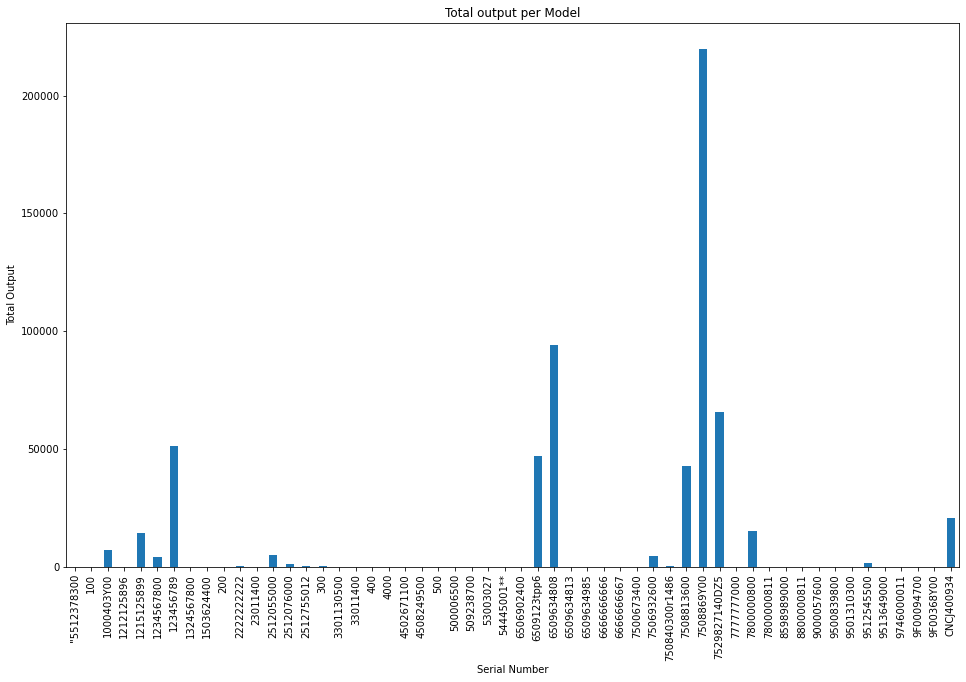

In [30]:
total_output_per_slno = usage_data.groupby('Serial Number')['Output_Total'].sum()

# Plot bar graph
plt.figure(figsize=(16, 10))
total_output_per_slno.plot(kind='bar')
plt.xlabel('Serial Number')
plt.ylabel('Total Output')
plt.title('Total output per Model')
plt.show()

In [31]:
total_output_per_slno

Serial Number
"5512378300            0
100                  117
1000403Y00          7145
1212125896             0
1215125899         14290
1234567800          4068
123456789          51216
1324567800             0
1503624400             0
200                    0
2222222222           351
23011400               0
2512055000          4975
2512076000           986
2512755012           234
300                  351
3301130500             0
33011400               0
400                    0
4000                   0
4502671100            15
4508249500             0
500                    0
500006500              0
509238700              0
53003027               0
54445001**             0
6506902400             0
6509123tpp6        47043
6509634808         94086
6509634813             0
6509634985             0
6666666666           117
6666666667             0
7500673400             0
7506932600          4658
750840300r1486       270
7508813600         42844
7508869Y00        219770
7529827140D

### Removing data of all serial numbers with zero output

In [32]:
slno_with_zero_output = total_output_per_slno[total_output_per_slno == 0].index 
usage_data_1 = usage_data[~usage_data['Serial Number'].isin(slno_with_zero_output)]
usage_data_1



,Start Date,End Date,Model Name,Serial Number,IP Address,Output_Total,Output Total_Black-White,Output Total_Color,Copy_Total,Copy_Black-White,...,Others_Color,Send_Total,Send_Black-White,Send_Color,Scan Send_Total,Scan Send_Black-White,Scan Send_Color,Scan to HDD_Total,Scan to HDD_Black-White,Scan to HDD_Color
1,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C36,2512076000,172.29.242.223,206,97,109,0,0.0,...,0,3,0,3,3,0.0,3,0,0.0,0
4,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-3560N,7506932600,172.29.242.156,343,22,321,1,1.0,...,0,388,88,300,388,88.0,300,0,0.0,0
5,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP MX-5070N,123456789,172.29.240.157,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
6,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,100,172.29.243.33,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
7,"1/8/2024, 12:00 AM","1/15/2024, 12:00 AM",SHARP BP-50C26,6666666666,172.29.241.60,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-50C26,2512055000,172.29.241.167,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
223,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-20C25,9F00368Y00,172.29.240.238,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
225,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP MX-6170FV,7508869Y00,10.36.102.45,0,0,0,0,0.0,...,0,0,0,0,0,0.0,0,0,0.0,0
226,"3/25/2024, 12:00 AM","4/1/2024, 12:00 AM",SHARP BP-50C26,2222222222,192.168.81.185,117,73,44,99,64.0,...,1,0,0,0,0,0.0,0,0,0.0,0


In [33]:
total_output_per_slno = usage_data_1.groupby('Serial Number')['Output_Total'].sum()

In [34]:
total_output_per_slno

Serial Number
100                  117
1000403Y00          7145
1215125899         14290
1234567800          4068
123456789          51216
2222222222           351
2512055000          4975
2512076000           986
2512755012           234
300                  351
4502671100            15
6509123tpp6        47043
6509634808         94086
6666666666           117
7506932600          4658
750840300r1486       270
7508813600         42844
7508869Y00        219770
7529827140DZ5      65568
7800000800         15131
9512545500          1497
9513649000            88
9F00368Y00            43
CNCJ400934         20878
Name: Output_Total, dtype: int64

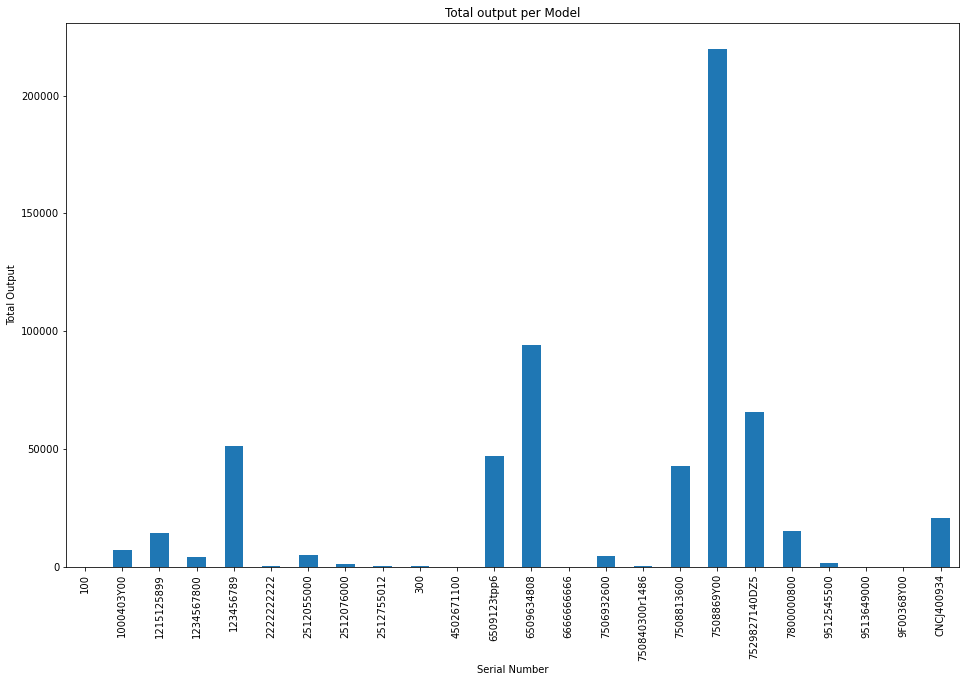

In [35]:
plt.figure(figsize=(16, 10))
total_output_per_slno.plot(kind='bar')
plt.xlabel('Serial Number')
plt.ylabel('Total Output')
plt.title('Total output per Model')
plt.show()

<ipython-input-51-f5b36dfd624f>:9: RuntimeWarning: invalid value encountered in long_scalars
  ratio = height1 / total


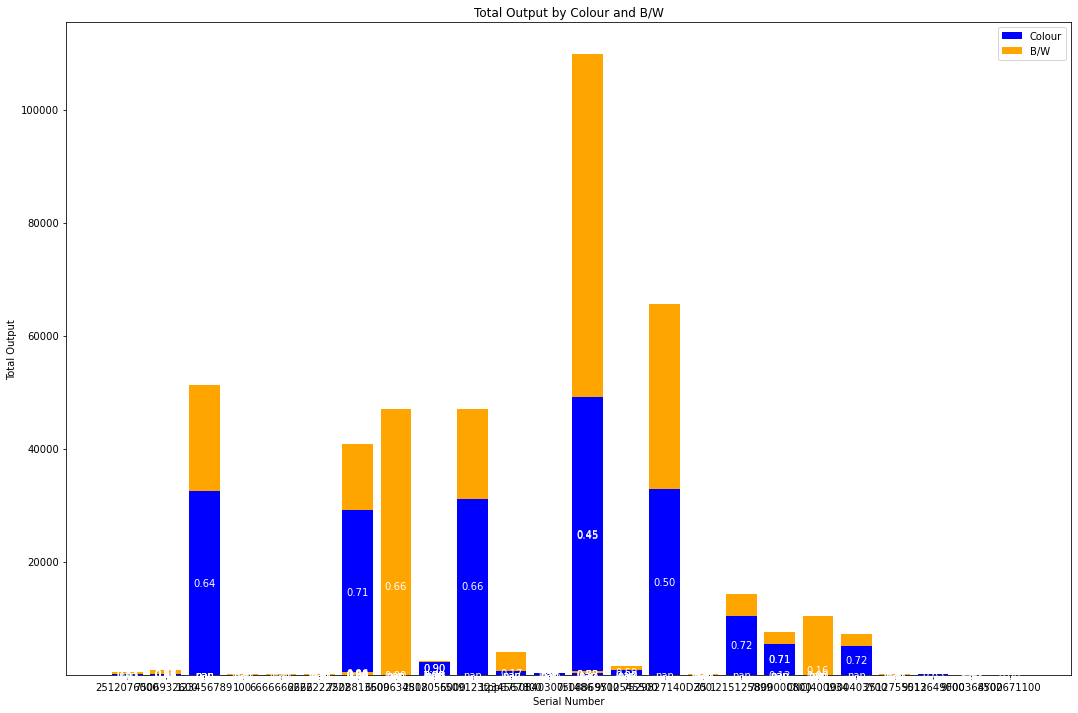

In [51]:
plt.figure(figsize=(18, 12))
bars1 = plt.bar(usage_data_1['Serial Number'], usage_data_1['Output Total_Color'], label='Colour', color='blue')
bars2 = plt.bar(usage_data_1['Serial Number'], usage_data_1['Output Total_Black-White'], bottom=usage_data_1['Output Total_Color'], label='B/W', color='orange')

for bar1, bar2 in zip(bars1, bars2):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    total = height1 + height2
    ratio = height1 / total
    plt.text(bar1.get_x() + bar1.get_width() / 2, height1 / 2, f'{ratio:.2f}', ha='center', va='center', color='white')

plt.xlabel('Serial Number')
plt.ylabel('Total Output')
plt.title('Total Output by Colour and B/W')
plt.legend()
plt.show()